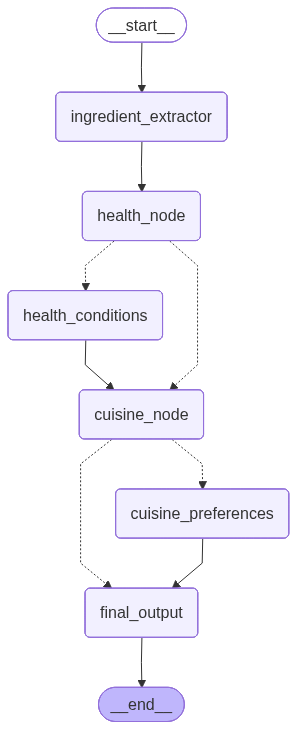

In [ ]:
from langgraph.graph import StateGraph
from typing import TypedDict, Dict, Any

# ----------------------------
# STATE DEFINITION
# ----------------------------
class MealState(TypedDict, total=False):
    raw_ingredients: list
    ingredients: list
    health_conditions: list
    cuisine_pref: list
    health_context: dict
    cuisine_context: dict
    final_output: dict


graph = StateGraph(MealState)

# ----------------------------
# NODES
# ----------------------------

# Extract ingredients
def extract_fn(state: Dict[str, Any]) -> Dict[str, Any]:
    state["ingredients"] = state.get("raw_ingredients", [])
    return state


# Process health conditions
def health_fn(state: Dict[str, Any]) -> Dict[str, Any]:
    state["health_context"] = {
        "conditions": state.get("health_conditions", []),
        "note": "Processed"
    }
    return state


# Router after health
def check_health_conditions(state: Dict[str, Any]) -> str:
    return "health_conditions" if state.get("health_conditions") else "cuisine_node"


# Process cuisine preferences
def cuisine_fn(state: Dict[str, Any]) -> Dict[str, Any]:
    state["cuisine_context"] = {
        "preferences": state.get("cuisine_pref", []),
        "note": "Processed"
    }
    return state


# Router after cuisine
def check_cuisine_preferences(state: Dict[str, Any]) -> str:
    return "cuisine_preferences" if state.get("cuisine_pref") else "final_output"


# Final output
def final_fn(state: Dict[str, Any]) -> Dict[str, Any]:
    ingredients = state.get("ingredients", [])
    conditions = state.get("health_conditions", [])
    cuisine_preferences = state.get("cuisine_pref", [])

    state["final_output"] = {
        "message": f"Recipe using {ingredients}",
        "health_note": f"Adjusted for {conditions}" if conditions else "No restrictions",
        "cuisine_note": f"Adjusted for {cuisine_preferences}" if cuisine_preferences else "Default: South Indian Veg"
    }
    return state


# ----------------------------
# ADD NODES
# ----------------------------
graph.add_node("ingredient_extractor", extract_fn)
graph.add_node("health_conditions", health_fn)
graph.add_node("cuisine_preferences", cuisine_fn)
graph.add_node("final_output", final_fn)

# Dummy router nodes (lightweight pass-through)
graph.add_node("health_node", lambda state: state)
graph.add_node("cuisine_node", lambda state: state)


# ----------------------------
# FLOW
# ----------------------------

# Entry
graph.set_entry_point("ingredient_extractor")

# Step 1 → Health routing
graph.add_edge("ingredient_extractor", "health_node")

graph.add_conditional_edges(
    "health_node",
    check_health_conditions,
    {
        "health_conditions": "health_conditions",
        "cuisine_node": "cuisine_node"
    }
)

# Step 2 → After health → cuisine decision
graph.add_edge("health_conditions", "cuisine_node")

graph.add_conditional_edges(
    "cuisine_node",
    check_cuisine_preferences,
    {
        "cuisine_preferences": "cuisine_preferences",
        "final_output": "final_output"
    }
)

# Step 3 → Final
graph.add_edge("cuisine_preferences", "final_output")

# Finish
graph.set_finish_point("final_output")


# ----------------------------
# COMPILE
# ----------------------------
app = graph.compile()


# ----------------------------
# VISUALIZE
# ----------------------------
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization failed:", e)

In [49]:
# ----------------------------
# TEST RUN
# ----------------------------
result = app.invoke({
    "raw_ingredients": ["carrot", "spinach"],
    "health_conditions": ["diabetes"],
    "cuisine_pref": ["South Indian"]
})


import pandas as pd
result_df = pd.DataFrame([result])
result_df


,raw_ingredients,ingredients,health_conditions,cuisine_pref,health_context,cuisine_context,final_output
0,"[carrot, spinach]","[carrot, spinach]",[diabetes],[South Indian],"{'conditions': ['diabetes'], 'note': 'Processed'}","{'preferences': ['South Indian'], 'note': 'Pro...","{'message': 'Recipe using ['carrot', 'spinach'..."


In [50]:
result_df.final_output[0]

{'message': "Recipe using ['carrot', 'spinach']",
 'health_note': "Adjusted for ['diabetes']",
 'cuisine_note': "Adjusted for ['South Indian']"}